# Decision Tree 

# Decision Tree for Classification from Scratch

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
class Node:
    def __init__(self,feature=None,threshold=None,left=None,right=None,value=None):
        self.feature = feature
        self.threshold= threshold
        self.left = left
        self.right = right
        self.value = value

In [3]:
class DecisionTree:
    def __init__(self, criterion='gini', max_depth=None, 
                 min_samples_split=2, min_samples_leaf=1,
                 max_features=None, min_impurity_decrease=0.0):
        self.criterion           = criterion
        self.max_depth           = max_depth
        self.min_samples_split   = min_samples_split
        self.min_samples_leaf    = min_samples_leaf
        self.max_features        = max_features
        self.min_impurity_decrease = min_impurity_decrease
        
    
    # Impurity functions
    def _gini(self,y):
        counts = np.bincount(y)
        prob = counts/len(y)
        return 1 - np.sum(prob ** 2)
    
    def _entropy(self,y):
        counts = np.bincount(y)
        counts = counts[counts>0]/len(y)
        return -np.sum(probs * np.log2(probs))
    
    def _impurity(self,y):
        return self._gini(y) if self.criterion=="gini" else self._entropy(y)
    
    def _information_gain(self,y,y_left,y_right):
        n = len(y)
        weighted = (len(y_left)/n)*self._impurity(y_left) +(len(y_right)/n)*self._impurity(y_right)
        return self._impurity(y) - weighted
    
    def _best_split(self, X, y):
        best_gain = -1
        best_feat = None
        best_thresh = None

        n_features = X.shape[1]

        features = np.random.choice(
            n_features,
            size=self.max_features or n_features,
            replace=False
        )

        for feat in features:
            thresholds = np.unique(X[:, feat])

            for thresh in thresholds:
                mask = X[:, feat] <= thresh
                y_left, y_right = y[mask], y[~mask]

                if len(y_left) < self.min_samples_leaf or len(y_right) < self.min_samples_leaf:
                    continue

                gain = self._information_gain(y, y_left, y_right)

                if gain > best_gain and gain >= self.min_impurity_decrease:
                    best_gain = gain
                    best_feat = feat
                    best_thresh = thresh

        return best_feat, best_thresh
    
    
    def _build(self, X, y, depth=0):
        # ---------- Stopping Conditions ----------
    
        # If all labels same
        if len(np.unique(y)) == 1:
            return Node(value=y[0])

        # If samples less than minimum split
        if len(y) < self.min_samples_split:
            return Node(value=Counter(y).most_common(1)[0][0])

        # If max depth reached
        if self.max_depth is not None and depth >= self.max_depth:
            return Node(value=Counter(y).most_common(1)[0][0])

        # ---------- Find Best Split ----------
        feat, thresh = self._best_split(X, y)

        # If no valid split found
        if feat is None or thresh is None:
            return Node(value=Counter(y).most_common(1)[0][0])

        # ---------- Split Data ----------
        mask = X[:, feat] <= thresh

        # Safety check
        if np.sum(mask) == 0 or np.sum(~mask) == 0:
            return Node(value=Counter(y).most_common(1)[0][0])

        # ---------- Recursive Tree Build ----------
        left = self._build(X[mask], y[mask], depth + 1)
        right = self._build(X[~mask], y[~mask], depth + 1)

        # ---------- Return Decision Node ----------
        return Node(
            feature=feat,
            threshold=thresh,
        left=left,
        right=right
    )

    def fit(self, X, y):
        self.root = self._build(np.array(X), np.array(y))
        return self

    def _predict_one(self, x, node):
        if node.value is not None:
            return node.value

        if node.feature is None or node.threshold is None:
            return node.value

        if x[node.feature] <= node.threshold:
            return self._predict_one(x, node.left)

        return self._predict_one(x, node.right)

    def predict(self, X):
        return np.array([self._predict_one(x, self.root) for x in X])

In [4]:
df = sns.load_dataset("iris")
print(df)
df["species"] = np.where(df["species"]=='setosa',1,0)
print(df)

     sepal_length  sepal_width  petal_length  petal_width    species
0             5.1          3.5           1.4          0.2     setosa
1             4.9          3.0           1.4          0.2     setosa
2             4.7          3.2           1.3          0.2     setosa
3             4.6          3.1           1.5          0.2     setosa
4             5.0          3.6           1.4          0.2     setosa
..            ...          ...           ...          ...        ...
145           6.7          3.0           5.2          2.3  virginica
146           6.3          2.5           5.0          1.9  virginica
147           6.5          3.0           5.2          2.0  virginica
148           6.2          3.4           5.4          2.3  virginica
149           5.9          3.0           5.1          1.8  virginica

[150 rows x 5 columns]
     sepal_length  sepal_width  petal_length  petal_width  species
0             5.1          3.5           1.4          0.2        1
1             

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
X = df[['sepal_length','sepal_width','petal_length','petal_width']].astype("float32").values
y = df['species'].astype("int").values

In [7]:
X_train,X_test,y_train,y_test  = train_test_split(X,y)

In [8]:
decisiontree = DecisionTree(criterion='gini')
decisiontree.fit(X_train,y_train)

In [9]:
predicted = decisiontree.predict(X_test)
print(predicted)

[0 0 1 1 0 0 0 0 0 1 1 0 0 1 0 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 0 1 0 1 0 1 0
 1]


In [10]:
from sklearn.metrics import f1_score,recall_score,accuracy_score,confusion_matrix,classification_report

In [11]:
print("accuracy score:",accuracy_score(predicted,y_test))
print("recall score:", recall_score(predicted,y_test))
print("f1 score:",f1_score(predicted,y_test))
print("confusion matrix",confusion_matrix(predicted,y_test))

accuracy score: 0.9473684210526315
recall score: 1.0
f1 score: 0.923076923076923
confusion matrix [[24  2]
 [ 0 12]]


# Implementation of Decision tree for Classification using sklearn

In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

In [13]:
df = sns.load_dataset("iris")
print(df)
df["species"] = np.where(df["species"]=='setosa',1,0)
print(df)

     sepal_length  sepal_width  petal_length  petal_width    species
0             5.1          3.5           1.4          0.2     setosa
1             4.9          3.0           1.4          0.2     setosa
2             4.7          3.2           1.3          0.2     setosa
3             4.6          3.1           1.5          0.2     setosa
4             5.0          3.6           1.4          0.2     setosa
..            ...          ...           ...          ...        ...
145           6.7          3.0           5.2          2.3  virginica
146           6.3          2.5           5.0          1.9  virginica
147           6.5          3.0           5.2          2.0  virginica
148           6.2          3.4           5.4          2.3  virginica
149           5.9          3.0           5.1          1.8  virginica

[150 rows x 5 columns]
     sepal_length  sepal_width  petal_length  petal_width  species
0             5.1          3.5           1.4          0.2        1
1             

In [14]:
X = df[['sepal_length','sepal_width','petal_length','petal_width']].astype("float32").values
y = df['species'].astype("int").values

In [15]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
# Create model
model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=3,
    random_state=42
)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)
print(y_pred)

[0 1 0 0 0 1 0 0 0 0 0 1 1 1 1 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1]


In [17]:
print("accuracy score:",accuracy_score(y_pred,y_test))
print("recall score:", recall_score(y_pred,y_test))
print("f1 score:",f1_score(y_pred,y_test))
print("confusion matrix:",confusion_matrix(y_pred,y_test))
print("classification report:",classification_report(y_pred,y_test))

accuracy score: 1.0
recall score: 1.0
f1 score: 1.0
confusion matrix: [[20  0]
 [ 0 10]]
classification report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



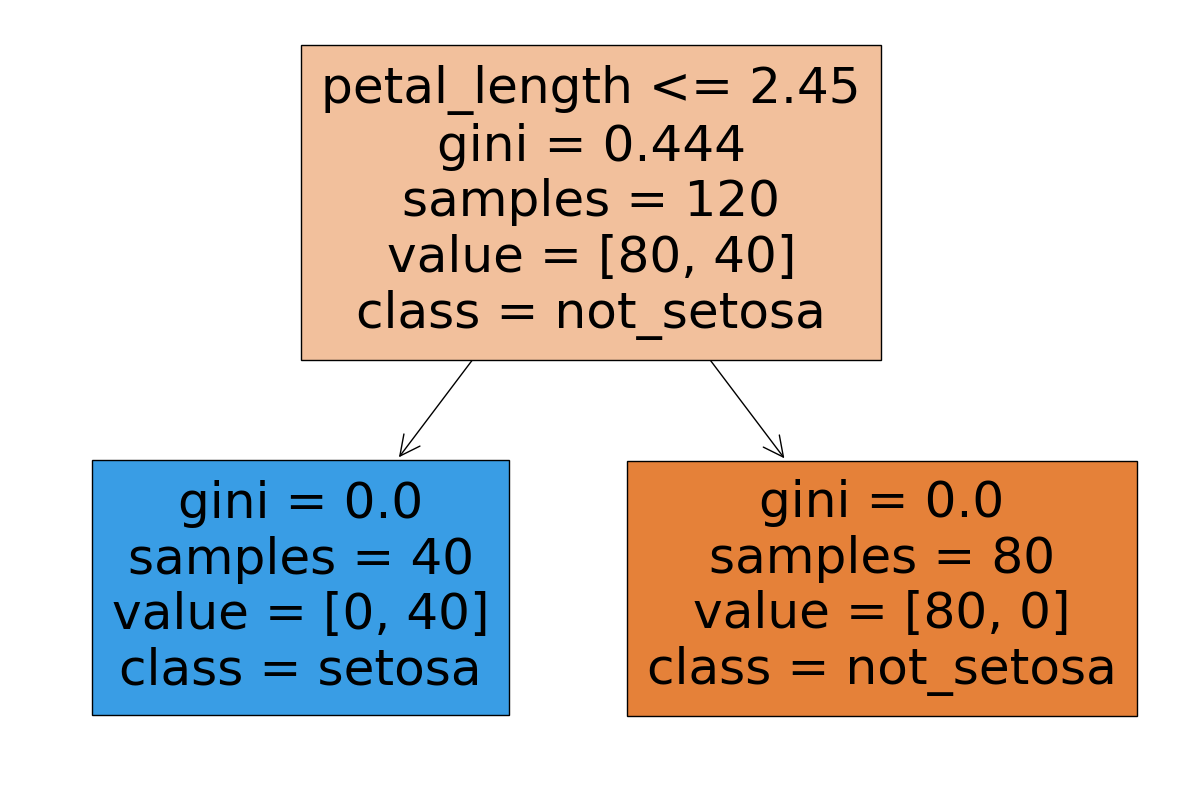

In [18]:
# Plot tree
plt.figure(figsize=(15,10))

plot_tree(
    model,
    filled=True,
    feature_names=["sepal_length","sepal_width","petal_length","petal_width"] ,
    class_names=["not_setosa", "setosa"]
)

plt.show()

# Implementation of Decision Tree for Regression 

In [19]:
import numpy as np
import matplotlib.pyplot as plt

In [20]:
class Node:

    def __init__(
        self,
        feature=None,
        threshold=None,
        left=None,
        right=None,
        value=None
    ):

        self.feature = feature
        self.threshold = threshold

        self.left = left
        self.right = right

        self.value = value

In [21]:
class DecisionTreeRegressorScratch:

    def __init__(
        self,
        min_samples_split=2,
        max_depth=3
    ):

        self.min_samples_split = min_samples_split
        self.max_depth = max_depth

        self.root = None

    def leaf_value(self, y):

        return np.mean(y)

    def best_split(self, X, y):

        best_feature = None
        best_threshold = None

        best_mse = float("inf")

        n_samples, n_features = X.shape

        for feature in range(n_features):

            thresholds = np.unique(X[:, feature])

            for threshold in thresholds:

                left_idx = X[:, feature] <= threshold
                right_idx = X[:, feature] > threshold

                if len(y[left_idx]) == 0 or len(y[right_idx]) == 0:
                    continue

                left_mse = np.var(y[left_idx])
                right_mse = np.var(y[right_idx])

                n_left = len(y[left_idx])
                n_right = len(y[right_idx])

                mse = (
                    n_left * left_mse +
                    n_right * right_mse
                ) / n_samples

                if mse < best_mse:

                    best_mse = mse

                    best_feature = feature
                    best_threshold = threshold

        return best_feature, best_threshold

    def build_tree(self, X, y, depth=0):

        n_samples, n_features = X.shape

        if (
            n_samples < self.min_samples_split
            or depth >= self.max_depth
        ):

            return Node(value=self.leaf_value(y))

        feature, threshold = self.best_split(X, y)

        if feature is None:

            return Node(value=self.leaf_value(y))

        left_idx = X[:, feature] <= threshold
        right_idx = X[:, feature] > threshold

        left_tree = self.build_tree(
            X[left_idx],
            y[left_idx],
            depth + 1
        )

        right_tree = self.build_tree(
            X[right_idx],
            y[right_idx],
            depth + 1
        )

        return Node(
            feature,
            threshold,
            left_tree,
            right_tree
        )

    def fit(self, X, y):

        self.root = self.build_tree(X, y)

    def traverse_tree(self, x, node):

        if node.value is not None:

            return node.value

        if x[node.feature] <= node.threshold:

            return self.traverse_tree(x, node.left)

        return self.traverse_tree(x, node.right)

    def predict(self, X):

        predictions = [
            self.traverse_tree(x, self.root)
            for x in X
        ]

        return np.array(predictions)

In [22]:
X = np.array([1,2,3,4,5,6,7,8]).reshape(-1,1)

y = np.array([2,3,4,5,8,9,10,12])

model = DecisionTreeRegressorScratch(
    max_depth=3
)

model.fit(X, y)

predictions = model.predict(X)

print(predictions)

[ 2.   3.   4.   5.   8.   9.5  9.5 12. ]


In [23]:
from sklearn.metrics import mean_squared_error,r2_score

In [24]:
print("Mearn squared Error",mean_squared_error(predictions,y))
print("r2score",r2_score(predictions,y))

Mearn squared Error 0.0625
r2score 0.9945280437756499


# Implementation of Decision Tree for Regression using sklearn

In [25]:
from sklearn.tree import DecisionTreeRegressor

In [26]:
X = np.array([1,2,3,4,5,6,7,8]).reshape(-1,1)

y = np.array([2,3,4,5,8,9,10,12])

model = DecisionTreeRegressor(
    criterion='squared_error',
    max_depth=3,
    random_state=42
)

model.fit(X, y)

predictions = model.predict(X)
print(y)
print(predictions)

[ 2  3  4  5  8  9 10 12]
[ 2.   3.   4.   5.   8.   9.5  9.5 12. ]


In [27]:
print("Mearn squared Error",mean_squared_error(predictions,y))
print("r2score",r2_score(predictions,y))

Mearn squared Error 0.0625
r2score 0.9945280437756499


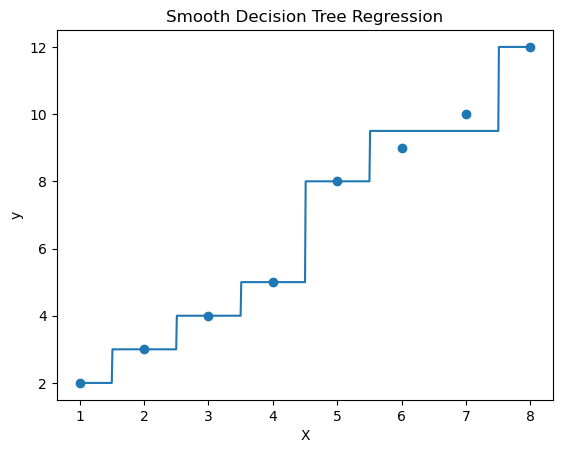

In [28]:
X_grid = np.arange(
    min(X),
    max(X),
    0.01
).reshape(-1,1)

y_grid = model.predict(X_grid)

plt.scatter(X, y)

plt.plot(X_grid, y_grid)

plt.title("Smooth Decision Tree Regression")

plt.xlabel("X")
plt.ylabel("y")

plt.show()